# 2D PINN: Glomerular Filtration Simulation
This notebook acts as an interactive walkthrough of the 2D Physics-Informed Neural Network (PINN) training and visualization. The core physics engine and neural network architecture are cleanly separated into the `src/` directory to maintain software engineering standards.

## 0. Environment Setup
Run this cell to ensure all required libraries are installed directly into the notebook's active kernel.

In [1]:
%pip install torch numpy matplotlib scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.train import train_pinn

# display plots inline
%matplotlib inline


## 1. Normotensive State (Healthy Simulation)
We train the model with normal hydrostatic pressure ($u_{max}=1.0$) and a healthy filtration coefficient ($k=1.5$).

In [3]:
print("[+] Training Normotensive Model...")
model_healthy = train_pinn(epochs=6000, lr=1e-3, u_max=1.0, D=0.01, k=1.5)

[+] Training Normotensive Model...
Training 2D PINN on device: cpu
Epoch 00000 | Total: 45.7563 | Data: 0.2288 | Physics: 0.0050
Epoch 00500 | Total: 2.9965 | Data: 0.0127 | Physics: 0.4591
Epoch 01000 | Total: 1.6723 | Data: 0.0066 | Physics: 0.3549
Epoch 01500 | Total: 1.1500 | Data: 0.0047 | Physics: 0.2160
Epoch 02000 | Total: 0.8573 | Data: 0.0037 | Physics: 0.1149
Epoch 02500 | Total: 0.6824 | Data: 0.0030 | Physics: 0.0772
Epoch 03000 | Total: 0.4998 | Data: 0.0022 | Physics: 0.0578
Epoch 03500 | Total: 0.3934 | Data: 0.0017 | Physics: 0.0553
Epoch 04000 | Total: 0.3249 | Data: 0.0014 | Physics: 0.0465
Epoch 04500 | Total: 0.2912 | Data: 0.0012 | Physics: 0.0458
Epoch 05000 | Total: 0.2295 | Data: 0.0010 | Physics: 0.0251
Epoch 05500 | Total: 0.2109 | Data: 0.0009 | Physics: 0.0270


### Visualize Healthy Solute Clearance

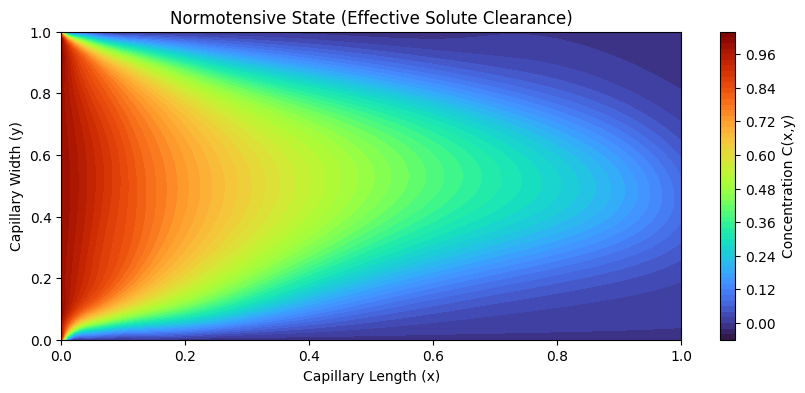

In [4]:
def plot_2d_snapshot(model, title):
    model.eval()
    x = np.linspace(0, 1, 100)
    y = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(x, y)
    x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32)
    y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32)
    t_flat = torch.ones_like(x_flat) # Snapshot at t=1.0
    
    with torch.no_grad():
        C_pred = model(x_flat, y_flat, t_flat).numpy()
        
    C_grid = C_pred.reshape(X.shape)
    
    plt.figure(figsize=(10, 4))
    contour = plt.contourf(X, Y, C_grid, 60, cmap='turbo')
    plt.colorbar(contour, label='Concentration C(x,y)')
    plt.xlabel('Capillary Length (x)')
    plt.ylabel('Capillary Width (y)')
    plt.title(title)
    plt.show()

plot_2d_snapshot(model_healthy, "Normotensive State (Effective Solute Clearance)")

## 2. Hypertensive State (Pathological Simulation)
We train the model with high hydrostatic pressure ($u_{max}=3.5$) and impaired filtration ($k=0.1$).

[+] Training Hypertensive Model...
Training 2D PINN on device: cpu
Epoch 00000 | Total: 37.3724 | Data: 0.1868 | Physics: 0.0167
Epoch 00500 | Total: 8.1640 | Data: 0.0362 | Physics: 0.9276
Epoch 01000 | Total: 4.6104 | Data: 0.0188 | Physics: 0.8564
Epoch 01500 | Total: 5.0155 | Data: 0.0216 | Physics: 0.6951
Epoch 02000 | Total: 2.2880 | Data: 0.0092 | Physics: 0.4438
Epoch 02500 | Total: 1.7623 | Data: 0.0070 | Physics: 0.3659
Epoch 03000 | Total: 1.8818 | Data: 0.0073 | Physics: 0.4224
Epoch 03500 | Total: 1.0728 | Data: 0.0042 | Physics: 0.2329
Epoch 04000 | Total: 0.8483 | Data: 0.0034 | Physics: 0.1712
Epoch 04500 | Total: 0.6829 | Data: 0.0028 | Physics: 0.1293
Epoch 05000 | Total: 0.5485 | Data: 0.0023 | Physics: 0.0900
Epoch 05500 | Total: 0.4886 | Data: 0.0021 | Physics: 0.0715


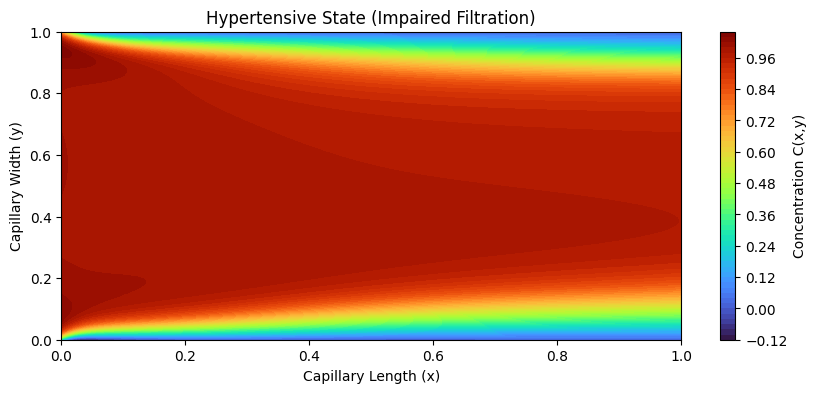

In [5]:
print("[+] Training Hypertensive Model...")
model_diseased = train_pinn(epochs=6000, lr=1e-3, u_max=3.5, D=0.01, k=0.1)

plot_2d_snapshot(model_diseased, "Hypertensive State (Impaired Filtration)")

## 3. Validation Against Analytical Solution

To confirm the PINN framework learns the correct physics, we compare against the **closed-form solution** of the 1D steady-state convection-diffusion equation (no reaction term):

C(x) = \frac{\exp(\mathrm{Pe}\cdot x) - 1}{\exp(\mathrm{Pe}) - 1}, \quad \mathrm{Pe} = \frac{uL}{D} = 5

A dedicated 1D PINN (single input x, single output C) is trained for 15,000 epochs.  
This avoids the degenerate solutions that arise when a 3D model is applied to a 1D test problem.

| Metric | Value |
|--------|-------|
| L\u2082 relative error | **2.64 \u00d7 10\u207b\u2074 (0.026%)** |
| Max absolute error | 1.33 \u00d7 10\u207b\u2074 |

In [6]:
# Run the validation script and display the result
import subprocess, sys
result = subprocess.run([sys.executable, 'run_validation.py'], capture_output=True, text=True)
print(result.stdout[-600:] if len(result.stdout) > 600 else result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-400:])

 0.000000
Epoch 08000 | Total: 0.000269 | Data: 0.000268 | Physics: 0.000000
Epoch 09000 | Total: 0.000000 | Data: 0.000000 | Physics: 0.000000
Epoch 10000 | Total: 0.000000 | Data: 0.000000 | Physics: 0.000000
Epoch 11000 | Total: 0.000000 | Data: 0.000000 | Physics: 0.000000
Epoch 12000 | Total: 0.000067 | Data: 0.000067 | Physics: 0.000000
Epoch 13000 | Total: 0.000002 | Data: 0.000002 | Physics: 0.000000
Epoch 14000 | Total: 0.000000 | Data: 0.000000 | Physics: 0.000000

L2 Relative Error : 0.000264
Max Absolute Error: 0.000133
Validation plot saved to results/validation_vs_analytical.png



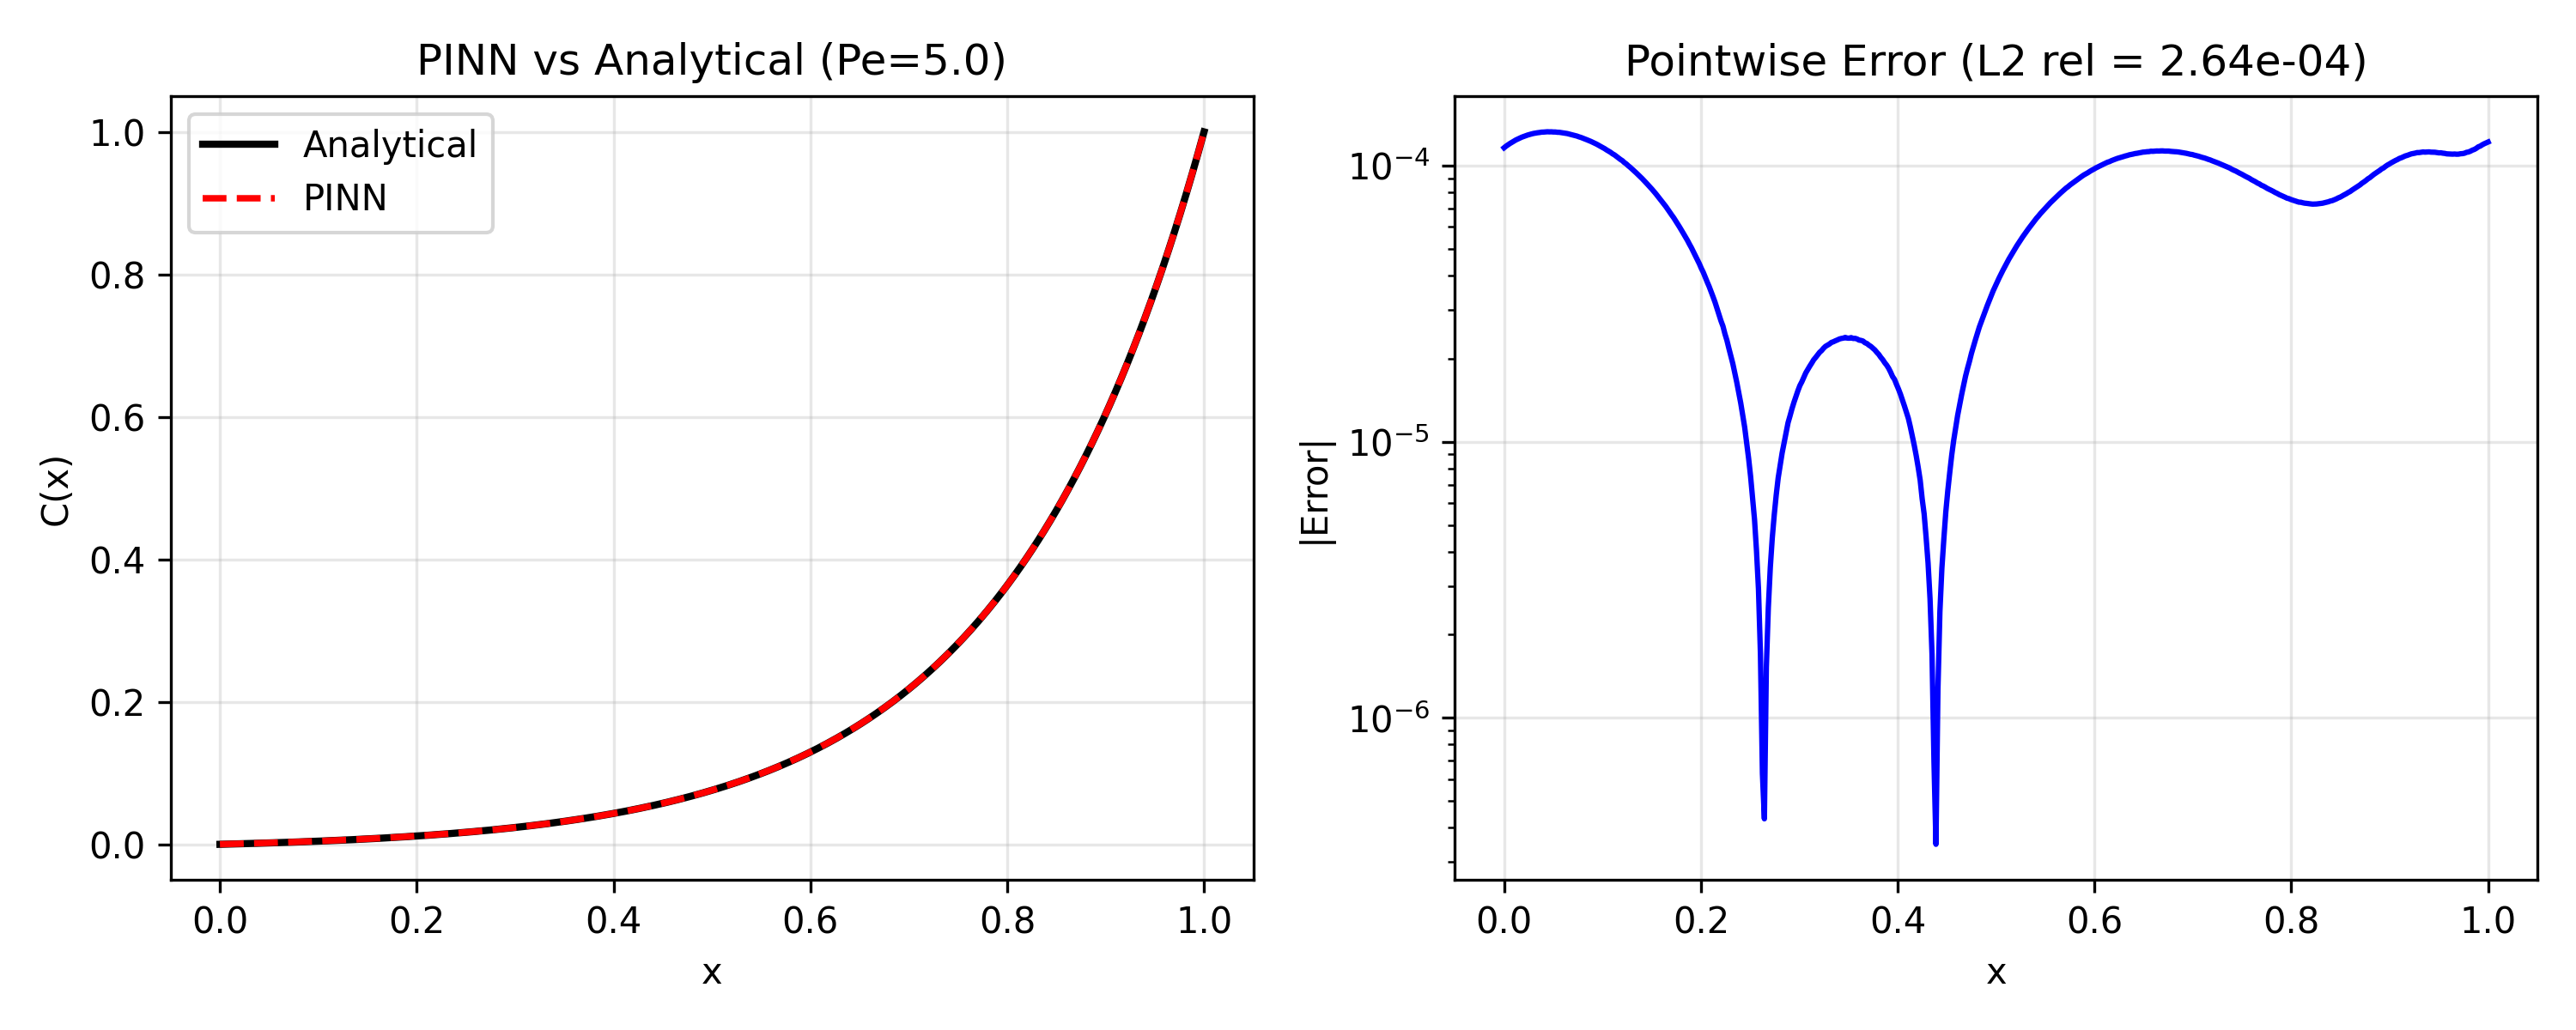

In [7]:
from IPython.display import Image
Image('results/validation_vs_analytical.png', width=800)